## Step 1: Import libraries

This cell imports the Python libraries used for data analysis and charts. Pandas and NumPy help with data work, while Matplotlib and Seaborn help to create visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

## Step 2: Load the datasets

This cell loads both CSV files into pandas DataFrames. It also prints the number of rows and columns, so we can quickly confirm that the files loaded correctly.

In [2]:
trader_df = pd.read_csv("historical_data.csv")
fg_df = pd.read_csv("fear_greed_index.csv")

print("Trader data shape:", trader_df.shape)
print("Fear/Greed data shape:", fg_df.shape)
trader_df.head()

Trader data shape: (211224, 16)
Fear/Greed data shape: (2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## Step 3: Clean trader data

This cell converts the trader timestamp into a proper date-time format. It also creates a separate Date column, because we need the trade date to join with the sentiment data.

In [3]:
trader_df['Timestamp IST'] = pd.to_datetime(trader_df['Timestamp IST'], format='%d-%m-%Y %H:%M')
trader_df['Date'] = trader_df['Timestamp IST'].dt.date
trader_df = trader_df.drop_duplicates()

## Step 4: Clean Fear and Greed data

This cell converts the sentiment date into the same date format as the trader data. It also renames columns to make the names easier to read and use.

In [4]:
fg_df['Date'] = pd.to_datetime(fg_df['date']).dt.date
fg_df = fg_df.rename(columns={'classification': 'Classification', 'value': 'Value'})

## Step 5: Merge both datasets

This cell joins the trader data with the Fear and Greed data using the Date column. After this step, every trade should have the market sentiment for that day.

In [5]:
merged_df = pd.merge(trader_df, fg_df[['Date', 'Value', 'Classification']], on='Date', how='left')
print("Merged shape:", merged_df.shape)

Merged shape: (211224, 19)


## Step 6: Keep only closed trades

This cell keeps only trades where Closed PnL is not zero. These trades are useful for performance analysis because they show realized profit or loss.

In [6]:
closed_trades = merged_df[merged_df['Closed PnL'] != 0].copy()

## Step 7: Compare PnL by sentiment

This cell groups closed trades by market sentiment. It calculates average PnL, median PnL, total PnL, and number of trades for each sentiment group.

In [7]:
avg_pnl = closed_trades.groupby('Classification')['Closed PnL'].agg(['mean','median','sum','count'])
avg_pnl = avg_pnl.sort_values('mean', ascending=False)
print(avg_pnl)

                      mean    median           sum  count
Classification                                           
Extreme Greed   130.205309  8.530740  2.715171e+06  20853
Fear            112.625988  6.350483  3.357155e+06  29808
Greed            85.403927  4.927600  2.150129e+06  25176
Neutral          71.199993  4.583458  1.292921e+06  18159
Extreme Fear     71.027316  6.388050  7.391102e+05  10406


## Step 8: Calculate win rate

This cell marks each closed trade as a win or loss. Then it calculates the win rate for each sentiment group.

In [8]:
closed_trades['is_win'] = closed_trades['Closed PnL'] > 0
win_rate = closed_trades.groupby('Classification')['is_win'].mean() * 100
print(win_rate.sort_values(ascending=False))

Classification
Extreme Greed    89.167026
Fear             87.288647
Neutral          82.388898
Greed            76.890690
Extreme Fear     76.215645
Name: is_win, dtype: float64


## Step 9: Compare trade size by sentiment

This cell checks the average trade size under each market sentiment. This helps us understand when traders are taking bigger positions.

In [9]:
avg_size = merged_df.groupby('Classification')['Size USD'].mean().sort_values(ascending=False)
print(avg_size)

Classification
Fear             7816.109931
Greed            5736.884375
Extreme Fear     5349.731843
Neutral          4782.732661
Extreme Greed    3112.251565
Name: Size USD, dtype: float64


## Step 10: Visualize basic results

This cell creates charts for average PnL, win rate, and PnL distribution by sentiment. Charts make it easier to compare patterns quickly.

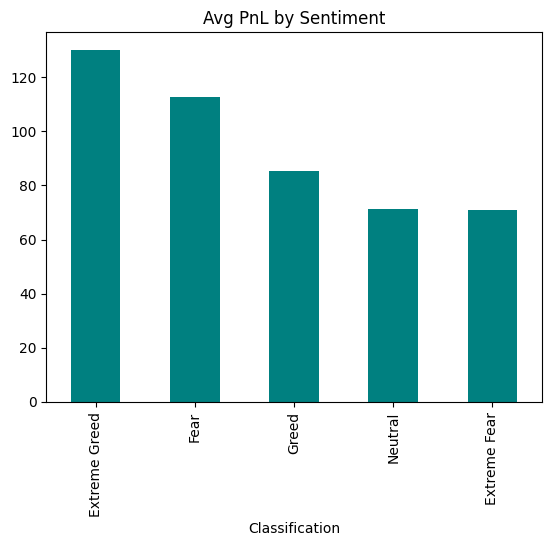

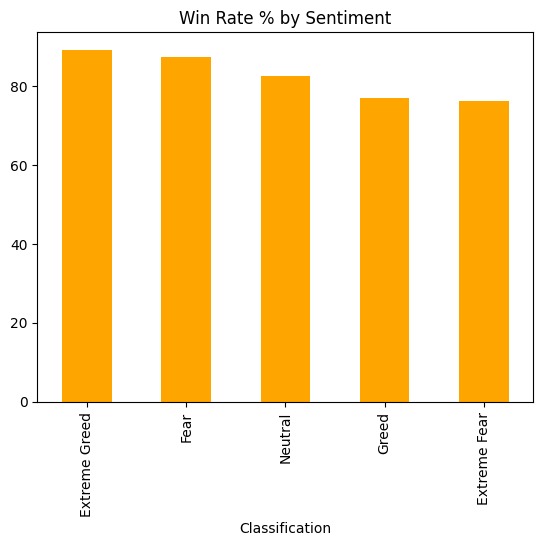

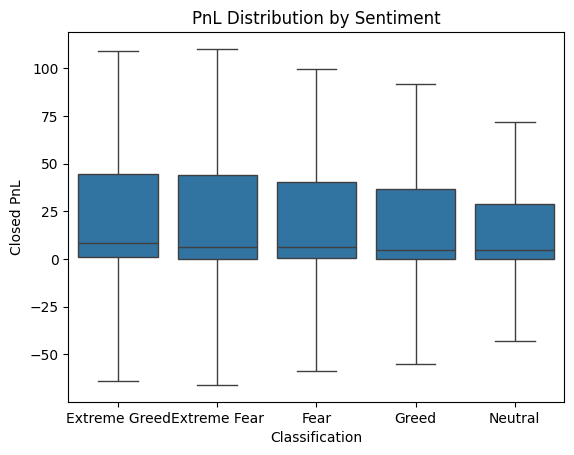

In [10]:
# Chart 1 - Avg PnL by sentiment
avg_pnl['mean'].plot(kind='bar', color='teal', title='Avg PnL by Sentiment')
plt.show()

# Chart 2 - Win rate by sentiment
win_rate.sort_values(ascending=False).plot(kind='bar', color='orange', title='Win Rate % by Sentiment')
plt.show()

# Chart 3 - Box plot
sns.boxplot(data=closed_trades, x='Classification', y='Closed PnL', showfliers=False)
plt.title('PnL Distribution by Sentiment')
plt.show()

## Step 11: Find top profitable accounts

This cell finds the top 10 accounts based on total realized Closed PnL. It helps identify which traders performed the best overall.

In [11]:
top_accounts = closed_trades.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False).head(10)
print(top_accounts)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64


## Step 12: Check data quality

This cell checks if any trades did not get a sentiment label after merging. It also checks missing values in important columns like PnL, size, fee, and sentiment.

In [12]:
missing_sentiment = merged_df['Classification'].isna().sum()
missing_pct = missing_sentiment / len(merged_df) * 100

print(f"Trades without sentiment label: {missing_sentiment:,} ({missing_pct:.2f}%)")
print("\nMissing values in key columns:")
print(merged_df[['Closed PnL', 'Size USD', 'Fee', 'Classification']].isna().sum())

Trades without sentiment label: 6 (0.00%)

Missing values in key columns:
Closed PnL        0
Size USD          0
Fee               0
Classification    6
dtype: int64


## Step 13: Build stronger performance metrics

This cell adds deeper metrics such as net PnL after fees, average fee, loss rate, average trade size, and profit factor. These metrics give a better view than average PnL alone.

In [13]:
closed_trades = closed_trades.copy()
closed_trades['Net PnL'] = closed_trades['Closed PnL'] - closed_trades['Fee']
closed_trades['is_loss'] = closed_trades['Closed PnL'] < 0

def profit_factor(series):
    gross_profit = series[series > 0].sum()
    gross_loss = abs(series[series < 0].sum())
    if gross_loss == 0:
        return np.nan
    return gross_profit / gross_loss

sentiment_summary = (
    closed_trades
    .groupby('Classification')
    .agg(
        trades=('Closed PnL', 'count'),
        gross_pnl=('Closed PnL', 'sum'),
        net_pnl=('Net PnL', 'sum'),
        avg_pnl=('Closed PnL', 'mean'),
        median_pnl=('Closed PnL', 'median'),
        avg_fee=('Fee', 'mean'),
        avg_trade_size=('Size USD', 'mean'),
        win_rate=('is_win', 'mean'),
        loss_rate=('is_loss', 'mean'),
        profit_factor=('Closed PnL', profit_factor),
    )
)

sentiment_summary['win_rate'] = sentiment_summary['win_rate'] * 100
sentiment_summary['loss_rate'] = sentiment_summary['loss_rate'] * 100
sentiment_summary = sentiment_summary.sort_values('net_pnl', ascending=False)
sentiment_summary.round(2)

,trades,gross_pnl,net_pnl,avg_pnl,median_pnl,avg_fee,avg_trade_size,win_rate,loss_rate,profit_factor
Classification,,,,,,,,,,
Fear,29808,3357155.44,3310156.23,112.63,6.35,1.58,8041.14,87.29,12.71,6.66
Extreme Greed,20853,2715171.31,2701505.45,130.21,8.53,0.66,2779.56,89.17,10.83,11.02
Greed,25176,2150129.27,2120451.59,85.40,4.93,1.18,5438.67,76.89,23.11,3.03
Neutral,18159,1292920.68,1270657.99,71.20,4.58,1.23,5556.44,82.39,17.61,4.32
Extreme Fear,10406,739110.25,726880.01,71.03,6.39,1.18,5467.57,76.22,23.78,2.16


## Step 14: Compare BUY and SELL trades

This cell checks trader performance separately for BUY and SELL trades under each sentiment. It helps show whether one side performs better in certain market moods.

In [14]:
side_summary = (
    closed_trades
    .groupby(['Classification', 'Side'])
    .agg(
        trades=('Closed PnL', 'count'),
        net_pnl=('Net PnL', 'sum'),
        avg_pnl=('Closed PnL', 'mean'),
        win_rate=('is_win', 'mean'),
        avg_trade_size=('Size USD', 'mean'),
    )
)

side_summary['win_rate'] = side_summary['win_rate'] * 100
side_summary.round(2)

trades     net_pnl  avg_pnl  win_rate  avg_trade_size
Classification Side                                                       
Extreme Fear   BUY     3123   370509.65   119.45     70.61         4093.80
               SELL    7283   356370.36    50.26     78.62         6056.65
Extreme Greed  BUY     6500   183550.77    28.98     85.95         3002.63
               SELL   14353  2517954.68   176.05     90.62         2678.54
Fear           BUY     9230  1919373.38   209.65     86.25         8184.97
               SELL   20578  1390782.85    69.11     87.75         7976.63
Greed          BUY    11343   602510.12    54.17     68.91         4585.28
               SELL   13833  1517941.47   111.02     83.43         6138.45
Neutral        BUY     5861   548999.18    94.59     77.68         3570.60
               SELL   12298   721658.81    60.05     84.63         6502.86

## Step 14A: Show BUY vs SELL as a heatmap

This cell turns the BUY vs SELL result into a heatmap. The heatmap makes it easier to see which sentiment and trade side has higher average PnL.

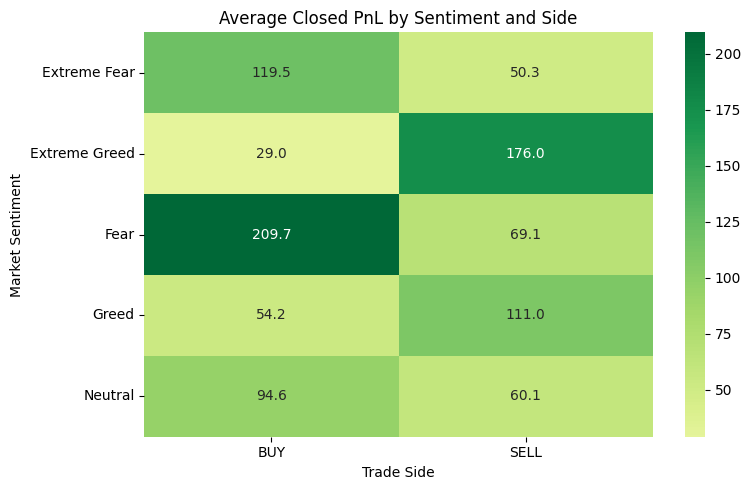

In [15]:
side_heatmap = side_summary['avg_pnl'].unstack()

plt.figure(figsize=(8, 5))
sns.heatmap(side_heatmap, annot=True, fmt='.1f', cmap='RdYlGn', center=0)
plt.title('Average Closed PnL by Sentiment and Side')
plt.xlabel('Trade Side')
plt.ylabel('Market Sentiment')
plt.tight_layout()
plt.show()

## Step 15: Check coin-level patterns

This cell looks at performance by coin and sentiment. It keeps only combinations with enough trades, so the result is more reliable.

In [16]:
coin_sentiment = (
    closed_trades
    .groupby(['Coin', 'Classification'])
    .agg(
        trades=('Closed PnL', 'count'),
        net_pnl=('Net PnL', 'sum'),
        avg_pnl=('Closed PnL', 'mean'),
        win_rate=('is_win', 'mean'),
    )
    .reset_index()
)

coin_sentiment['win_rate'] = coin_sentiment['win_rate'] * 100
coin_sentiment = coin_sentiment[coin_sentiment['trades'] >= 50]
top_coin_sentiment = coin_sentiment.sort_values('net_pnl', ascending=False).head(15)
top_coin_sentiment.round(2)

,Coin,Classification,trades,net_pnl,avg_pnl,win_rate
7,@107,Extreme Greed,6341,1986971.98,313.61,92.15
276,HYPE,Fear,13537,834094.76,62.07,89.68
469,SOL,Fear,2061,736275.75,359.82,95.00
9,@107,Greed,5038,722801.75,143.78,76.50
216,ETH,Fear,1428,672134.63,472.73,83.19
274,HYPE,Extreme Fear,4761,479440.90,101.26,85.68
173,BTC,Fear,4342,452815.59,111.16,87.63
470,SOL,Greed,507,449525.41,890.91,89.74
217,ETH,Greed,1557,346694.87,225.46,59.54
471,SOL,Neutral,810,300775.98,374.54,90.12


## Step 16: Find best accounts by sentiment

This cell finds the best accounts inside each sentiment group. This is useful because some traders may perform well only in specific market conditions.

In [17]:
account_sentiment = (
    closed_trades
    .groupby(['Account', 'Classification'])
    .agg(
        trades=('Closed PnL', 'count'),
        net_pnl=('Net PnL', 'sum'),
        avg_pnl=('Closed PnL', 'mean'),
        win_rate=('is_win', 'mean'),
    )
    .reset_index()
)

account_sentiment['win_rate'] = account_sentiment['win_rate'] * 100
account_sentiment = account_sentiment[account_sentiment['trades'] >= 20]
best_accounts_by_sentiment = (
    account_sentiment
    .sort_values(['Classification', 'net_pnl'], ascending=[True, False])
    .groupby('Classification')
    .head(5)
)

best_accounts_by_sentiment.round(2)

,Account,Classification,trades,net_pnl,avg_pnl,win_rate
136,0xbaaaf6571ab7d571043ff1e313a9609a10637864,Extreme Fear,1700,260504.23,154.07,100.00
76,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,Extreme Fear,187,198848.41,1063.64,49.73
54,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,Extreme Fear,311,165527.83,536.00,98.07
0,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Fear,37,124697.35,3372.14,100.00
59,0x4f93fead39b70a1824f981a54d4e55b278e9f760,Extreme Fear,159,72754.55,467.59,100.00
129,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Extreme Greed,893,1104593.13,1237.74,93.84
146,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,Extreme Greed,4520,477482.97,105.93,88.69
82,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,Extreme Greed,3434,210223.63,61.36,95.34
60,0x4f93fead39b70a1824f981a54d4e55b278e9f760,Extreme Greed,890,122353.45,145.19,91.69
16,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,Extreme Greed,3939,107436.21,27.42,84.41


## Step 17: Create a daily-level summary

This cell groups trades by day and sentiment. Daily aggregation reduces trade-level noise and shows whether the sentiment pattern still exists at a broader level.

In [18]:
daily_summary = (
    closed_trades
    .groupby(['Date', 'Classification'])
    .agg(
        daily_trades=('Closed PnL', 'count'),
        daily_net_pnl=('Net PnL', 'sum'),
        daily_avg_pnl=('Closed PnL', 'mean'),
        daily_win_rate=('is_win', 'mean'),
    )
    .reset_index()
)

daily_sentiment_summary = (
    daily_summary
    .groupby('Classification')
    .agg(
        days=('Date', 'count'),
        avg_daily_net_pnl=('daily_net_pnl', 'mean'),
        median_daily_net_pnl=('daily_net_pnl', 'median'),
        avg_daily_win_rate=('daily_win_rate', 'mean'),
    )
)

daily_sentiment_summary['avg_daily_win_rate'] = daily_sentiment_summary['avg_daily_win_rate'] * 100
daily_sentiment_summary.sort_values('avg_daily_net_pnl', ascending=False).round(2)

,days,avg_daily_net_pnl,median_daily_net_pnl,avg_daily_win_rate
Classification,,,,
Extreme Fear,14,51920.00,21947.29,65.44
Fear,75,44135.42,6622.97,88.07
Extreme Greed,108,25013.94,3521.41,88.65
Neutral,55,23102.87,5219.38,79.38
Greed,167,12697.31,898.25,81.30


## Step 18: Final Insights and Strategy Suggestions

### Key Findings

- **Extreme Greed periods show the strongest trader performance** — 89.2% win rate and the highest average PnL ($130.2 per trade), but with the smallest average trade size ($3,112). This may suggest that traders take smaller, more controlled positions during euphoric market conditions, resulting in high win rates but limited scale.

- **Fear periods also show unexpectedly strong performance** — 87.3% win rate with the second-highest average PnL ($112.6), while traders place significantly larger bets here ($7,816 average trade size — the highest of all sentiment categories). This indicates that disciplined or well-capitalized traders may be using fear-driven dips as high-conviction opportunities.

- **Extreme Fear has the weakest performance** — the lowest win rate (76.2%) among all sentiment categories, despite being another fear-based state. This points to a higher chance of panic-driven or impulsive trading during extreme downturns rather than calculated entries.

- **Greed periods underperform relative to Extreme Greed** — win rate drops to 76.9% with moderate trade sizes ($5,737), suggesting traders may be overextending or chasing momentum without the same discipline seen in extreme conditions.

- **Performance is highly concentrated among a few accounts** — the top trader alone generated over $2.1M in realized PnL, indicating that skill, timing, and strategy discipline matter more than market sentiment alone in determining outcomes.

### Strategy Recommendations

- **Reduce position size during Extreme Greed periods** — while win rates are high, profit per trade remains limited and crowd-driven optimism can increase reversal risk.

- **Use Fear periods as selective high-conviction entry points** — the data suggests disciplined traders may perform well by taking calculated, larger positions when the broader market is fearful.

- **Exercise caution during Extreme Fear** — this period shows the weakest win rate, so reducing trade frequency and applying strict risk management may help avoid panic-driven losses.

- **Track individual trader consistency across sentiment regimes** — since a small number of accounts drive most profits, studying consistent trader behavior may be more useful than reacting to sentiment alone.

### Final Note

These insights are based on observed historical relationships between trader performance and market sentiment. They should be interpreted as strategic signals, not guaranteed trading rules. Sentiment can support decision-making, but risk management, trader discipline, and position sizing remain the most important factors.
